<a href="https://colab.research.google.com/github/AbdulMuizz789/PixelFinder/blob/main/PixelFind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import statements
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt

In [2]:
#Function to generate all images
def generate_images(img_size=50):
    num_images = img_size * img_size
    images = np.zeros((num_images, img_size, img_size, 1), np.uint8)
    coords = np.zeros((num_images, 2), np.float32)

    i = 0
    for x in range(img_size):
        for y in range(img_size):
            images[i, y, x, 0] = 255
            coords[i] = [x / (img_size - 1), y / (img_size - 1)]
            i += 1

    return images, coords

In [3]:
#Store dataset, X -> images, Y-> coordinates
X, Y = generate_images()

dataset = tf.data.Dataset.from_tensor_slices((X, Y))

#Normalize data
normalize_layer = layers.Rescaling(1./255)
dataset = dataset.map(lambda x, y: (normalize_layer(x), y))

#Training and Validation data split
train_dataset, test_dataset = keras.utils.split_dataset(dataset,
    left_size=0.8, shuffle=True)

#Add batching
train_dataset = train_dataset.batch(32)
test_dataset = test_dataset.batch(32)

print(tf.data.experimental.cardinality(train_dataset).numpy())
print(tf.data.experimental.cardinality(test_dataset).numpy())

63
16


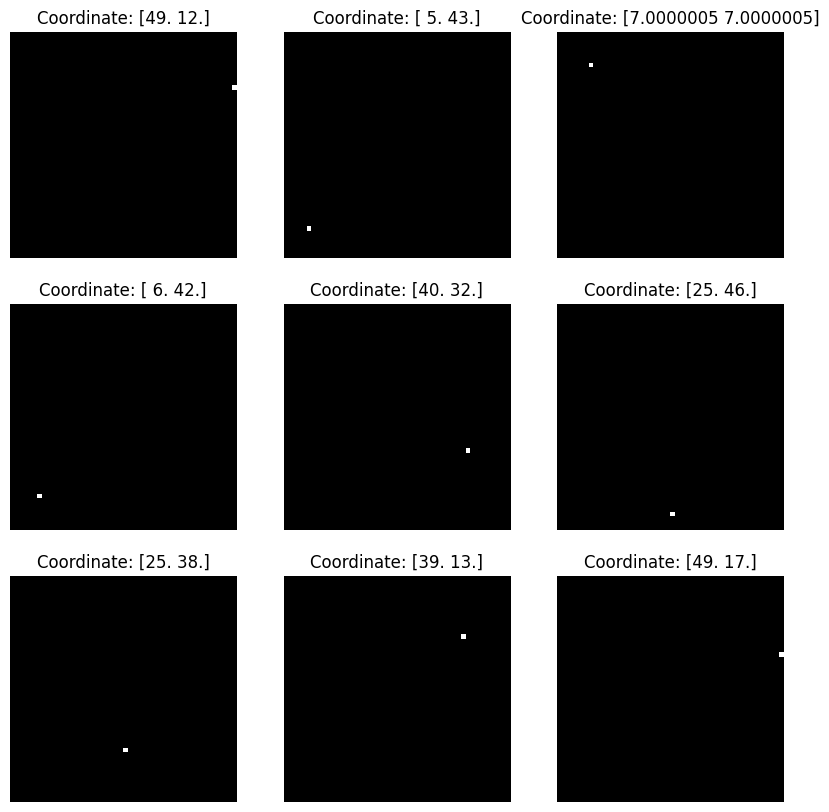

In [6]:
#Show first 9 images
plt.figure(figsize = (10,10))
for image_batch, label_batch in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy(), cmap='gray', vmin=0, vmax=1.0)
        label = label_batch[i].numpy() * 49
        plt.title(f'Coordinate: {label}')
        plt.axis('off')

In [7]:
#Create model
model = keras.Sequential([
    layers.InputLayer((50,50,1)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2)
])

#Compile Model
model.compile(optimizer='adam',
              loss = keras.losses.MeanSquaredError(),
              metrics=['mae'])

#Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,594 (1.22 MB)

 Trainable params: 318,594 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Training model
epochs=10
history = model.fit(
  train_dataset,
  validation_data=test_dataset,
  epochs=epochs
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.1185 - mae: 0.2487 - val_loss: 0.0055 - val_mae: 0.0479
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0039 - mae: 0.0410 - val_loss: 0.0016 - val_mae: 0.0238
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0015 - mae: 0.0268 - val_loss: 0.0010 - val_mae: 0.0190
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0011 - mae: 0.0232 - val_loss: 6.9522e-04 - val_mae: 0.0171
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0011 - mae: 0.0237 - val_loss: 5.6663e-04 - val_mae: 0.0164
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 7.9372e-04 - mae: 0.0206 - val_loss: 6.5633e-04 - val_mae: 0.0184
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 7.6786e-04 - mae: 0.0202 - val_loss: 4.6573e-04 - val_mae: 0.0142
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 7.6099e-04 - mae: 0.0200 - val_loss: 4.4215e-04 - val_mae: 0.0152
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━

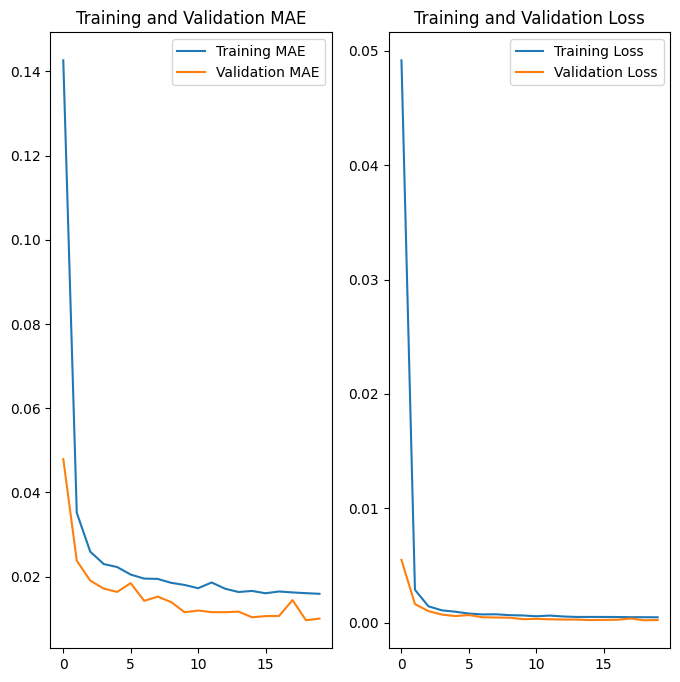

In [9]:
#Visualize results
mae = history.history['mae']
val_mae = history.history['val_mae']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, mae, label='Training MAE')
plt.plot(epochs_range, val_mae, label='Validation MAE')
plt.legend(loc='upper right')
plt.title('Training and Validation MAE')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


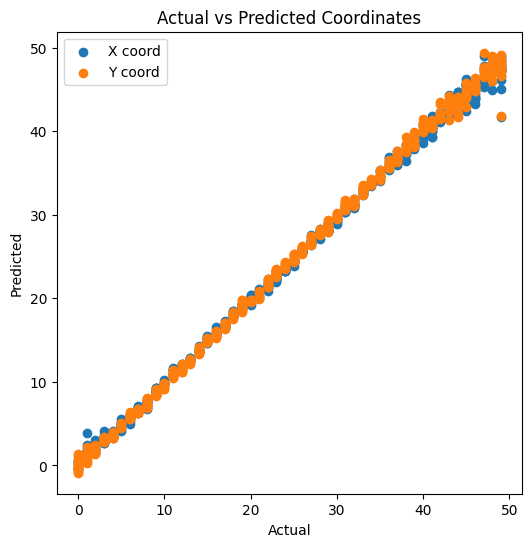

In [11]:
#Visualize predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.append(labels.numpy())
    y_pred.append(preds)

y_true = np.vstack(y_true) * 49
y_pred = np.vstack(y_pred) * 49

plt.figure(figsize=(6,6))
plt.scatter(y_true[:,0],y_pred[:,0], label='X coord')
plt.scatter(y_true[:,1],y_pred[:,1], label='Y coord')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.title('Actual vs Predicted Coordinates')
plt.show()